**Checklist**
- [ ] Seasonality
- [ ] Trend
- [ ] Compare seasonality of two different years
- [ ] Rolling mean
- [ ] Future prediction of number of launches

In [1]:
# Import

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../data/space_devs_launches_cleaned.csv')

# Datetime didn't save to csv file for whatever reason
df['launch_datetime'] = pd.to_datetime(df['launch_datetime'], errors='coerce')
df['launch_window_start'] = pd.to_datetime(df['launch_window_start'], errors='coerce')
df['launch_window_end'] = pd.to_datetime(df['launch_window_end'], errors='coerce')

In [9]:
df

,launch_id,launch_name,launch_designator,launch_datetime,launch_window_end,launch_window_start,failure_reason,status,status_abbrev,launch_provider,...,orbit,orbit_abbrev,launch_pad,launch_location,launch_country,pad_latitude,pad_longitude,year,month,quarter
0,bb643566-508a-4f3a-a701-85669d11e2b3,Long March 3C | Compass-G1,2010-001,2010-01-16 16:12:04+00:00,2010-01-16 16:12:04+00:00,2010-01-16 16:12:04+00:00,NaN,Launch Successful,Success,China Aerospace Science and Technology Corpora...,...,NaN,NaN,Launch Complex 2 (LC-2),"Xichang Satellite Launch Center, People's Repu...",China,28.245504,102.026768,2010,1,1
1,470aff2b-3cc8-4e98-9ada-d511828b4676,Proton-M / Briz-M Enhanced | Globus-1M #12L (R...,2010-002,2010-01-28 00:18:00+00:00,2010-01-28 00:18:00+00:00,2010-01-28 00:18:00+00:00,NaN,Launch Successful,Success,Khrunichev State Research and Production Space...,...,NaN,NaN,81/24 (81P),"Baikonur Cosmodrome, Republic of Kazakhstan",Kazakhstan,46.071001,62.984999,2010,1,1
2,cb3977fe-3ef4-46d2-8bc9-65a0d9cef07a,Soyuz-U | Progress M-04M (36P),2010-003,2010-02-03 03:45:30+00:00,2010-02-03 03:45:30+00:00,2010-02-03 03:45:30+00:00,NaN,Launch Successful,Success,Russian Federal Space Agency (ROSCOSMOS),...,NaN,NaN,1/5,"Baikonur Cosmodrome, Republic of Kazakhstan",Kazakhstan,45.920000,63.342000,2010,2,1
3,80db2215-04bd-4d16-b998-311fb73db4fe,Space Shuttle Endeavour / OV-105 | STS-130,2010-004,2010-02-08 09:14:08+00:00,2010-02-08 09:14:08+00:00,2010-02-08 09:14:08+00:00,NaN,Launch Successful,Success,United Space Alliance,...,Low Earth Orbit,LEO,Launch Complex 39A,"Kennedy Space Center, FL, USA",United States of America,28.608227,-80.604282,2010,2,1
4,7e4160fc-c9d5-4db6-b9b1-166408741f0e,Atlas V 401 | SDO (Solar Dynamics Observatory),2010-005,2010-02-11 15:23:00+00:00,2010-02-11 15:23:00+00:00,2010-02-11 15:23:00+00:00,NaN,Launch Successful,Success,United Launch Alliance,...,Enhanced Geostationary Transfer Orbit,Enhanced-GTO,Space Launch Complex 41,"Cape Canaveral SFS, FL, USA",United States of America,28.583410,-80.583036,2010,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2464,3a4dc969-d264-48a1-b113-bf69a798a5c4,H3-24 | Lunar Polar Exploration Mission (LUPEX),NaN,2026-12-31 00:00:00+00:00,2026-12-31 00:00:00+00:00,2026-12-31 00:00:00+00:00,NaN,To Be Determined,TBD,Mitsubishi Heavy Industries,...,Lunar Orbit,LO,Yoshinobu Launch Complex LP-2,"Tanegashima Space Center, Japan",Japan,30.400938,130.975640,2026,12,4
2465,06201706-da6b-467e-83b2-ef2ff8596e05,Vulcan | USSF-23,NaN,2026-12-31 00:00:00+00:00,2026-12-31 00:00:00+00:00,2026-12-31 00:00:00+00:00,NaN,To Be Determined,TBD,United Launch Alliance,...,Unknown,NaN,Space Launch Complex 41,"Cape Canaveral SFS, FL, USA",United States of America,28.583410,-80.583036,2026,12,4
2466,0c26b3d4-43e3-4c1a-8976-592ff319bc51,Falcon 9 Block 5 | Nova-C IM-3,NaN,2026-12-31 00:00:00+00:00,2026-12-31 00:00:00+00:00,2026-12-31 00:00:00+00:00,NaN,To Be Determined,TBD,SpaceX,...,Lunar Orbit,LO,Unknown Pad,"Cape Canaveral SFS, FL, USA",United States of America,28.458000,-80.528000,2026,12,4
2467,317a2749-46be-45e3-93f7-fbaecba04ac6,Vulcan | SDA Tranche 1 Tracking Layer B,NaN,2026-12-31 00:00:00+00:00,2026-12-31 00:00:00+00:00,2026-12-31 00:00:00+00:00,NaN,To Be Determined,TBD,United Launch Alliance,...,Polar Orbit,PO,Space Launch Complex 3E,"Vandenberg SFB, CA, USA",United States of America,34.640000,-120.589500,2026,12,4


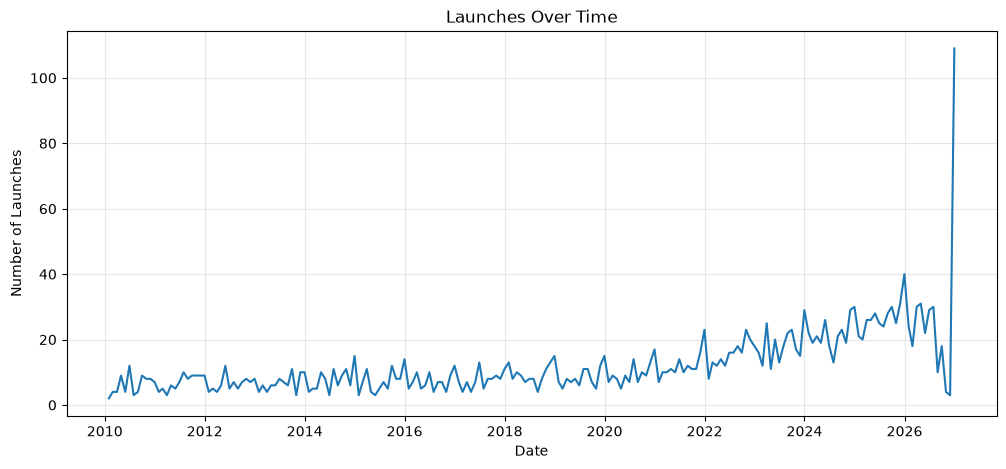

In [2]:
# Looking at launches over time

launches_by_month = (
    df.set_index('launch_datetime')
    .resample("ME")
    .size()
)

plt.figure(figsize=(12, 5))
plt.plot(launches_by_month.index, launches_by_month.values)
plt.title("Launches Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Launches")
plt.grid(True, alpha=0.3)
plt.show()

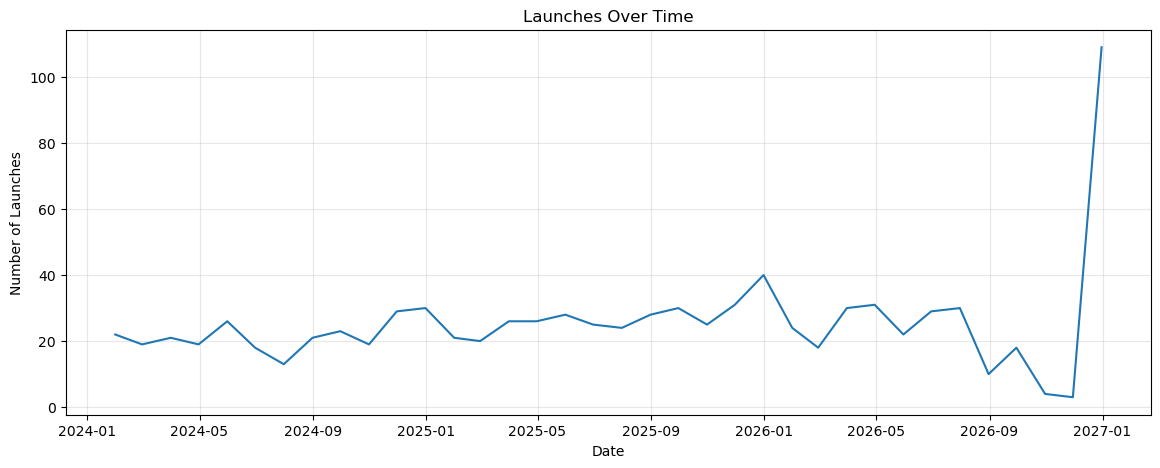

In [27]:
# Closer look at the last three years

last3_yrs_launches_by_month = launches_by_month.loc['2024-01-01':]

plt.figure(figsize=(14, 5))
plt.plot(last3_yrs_launches_by_month.index, last3_yrs_launches_by_month.values)
plt.title("Launches Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Launches")
plt.grid(True, alpha=0.3)
plt.show()

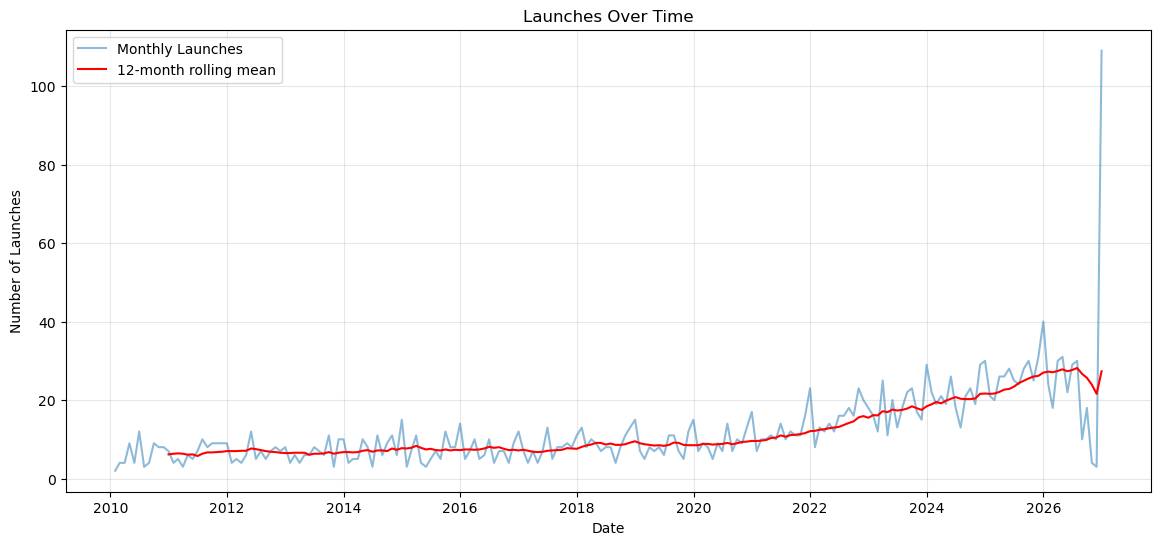

In [ ]:
# Rolling Mean

rolling_mean = launches_by_month.rolling(window=12).mean()

plt.figure(figsize=(14, 6))

plt.plot(launches_by_month.index, launches_by_month.values, alpha=0.5, label="Monthly Launches")
plt.plot(rolling_mean.index, rolling_mean.values, linewidth=1.5, color='red', label='12-month rolling mean')

plt.title("Launches Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Launches")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Overall trend of increasing number of launches over time

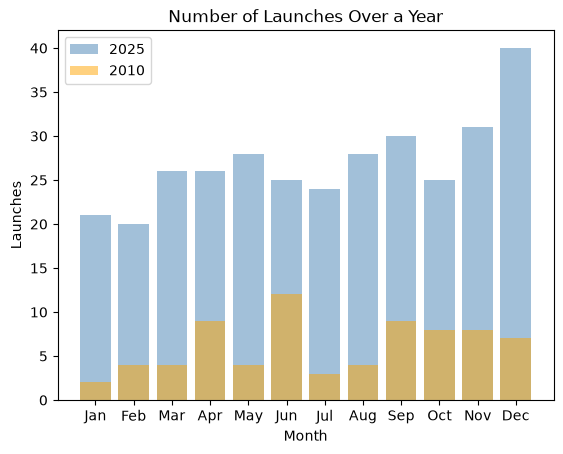

In [3]:
# Launches in the year 2010 vs. 2025

launches_by_month.index = pd.to_datetime(launches_by_month.index)

launches_2010 = launches_by_month[launches_by_month.index.year == 2010]
launches_2025 = launches_by_month[launches_by_month.index.year == 2025]

months = launches_2010.index.strftime('%b')

fig, ax = plt.subplots()

ax.bar(months, launches_2025, color='steelblue', alpha=0.5, label='2025')
ax.bar(months, launches_2010, color='orange', alpha=0.5, label='2010')


ax.set_xlabel('Month')
ax.set_ylabel('Launches')
ax.set_title('Number of Launches Over a Year')
ax.legend()

plt.show()

# Seems to be no clear seasonality for launches in a year

In [14]:
# Reformat the data for Prophet

df_prophet = launches_by_month.reset_index()
df_prophet.columns = ['ds', 'y']

# Removing timezone
df_prophet['ds'] = pd.to_datetime(df_prophet['ds']).dt.tz_localize(None)

df_prophet

,ds,y
0,2010-01-31,2
1,2010-02-28,4
2,2010-03-31,4
3,2010-04-30,9
4,2010-05-31,4
...,...,...
199,2026-08-31,10
200,2026-09-30,18
201,2026-10-31,4
202,2026-11-30,3


14:51:08 - cmdstanpy - INFO - Chain [1] start processing
14:51:08 - cmdstanpy - INFO - Chain [1] done processing


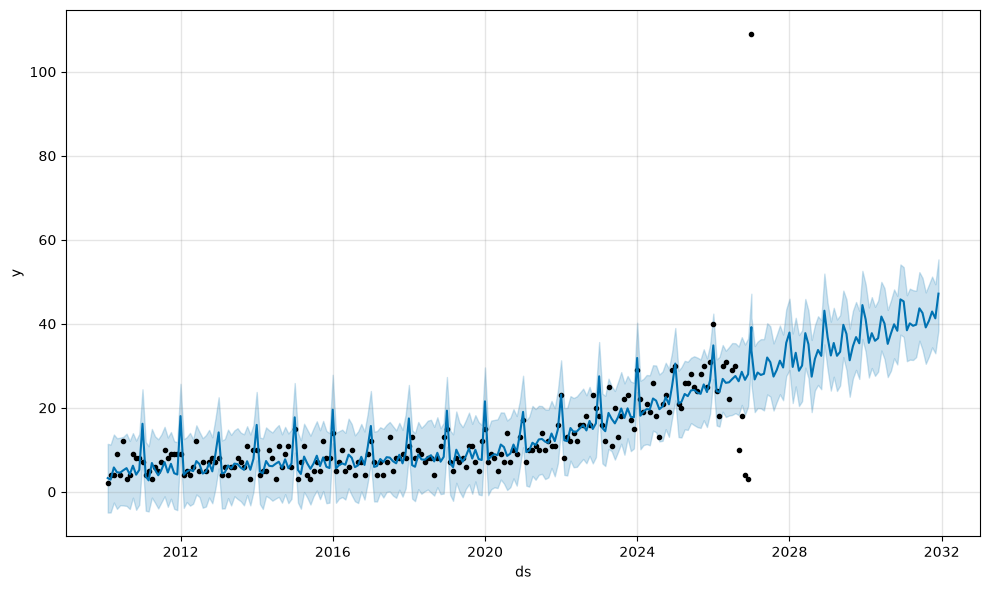

In [16]:
from prophet import Prophet 

model = Prophet()
model.fit(df_prophet)
future = model.make_future_dataframe(periods=60, freq="MS")
forecast = model.predict(future)

fig = model.plot(forecast)
plt.show()
